In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
SAVE_DIR = Path(r"C:\Users\rainc\OneDrive\Desktop\futures\finm37000\data")
years = range(2015, 2026)

frames = []

for year in years:
    df = pd.read_parquet(SAVE_DIR / f"ohlcv_{year}.parquet")

    # If ts_event is the index, move it to a column
    if df.index.name == "ts_event" and "ts_event" not in df.columns:
        df = df.reset_index()

    df["year"] = year
    df["date"] = df["ts_event"].dt.date
    frames.append(df)

# One big DataFrame with all years
full = pd.concat(frames, ignore_index=True)

# Coverage / symbol summary
coverage = (
    full.groupby("year")
        .agg(
            rows=("close", "size"),
            start=("ts_event", "min"),
            end=("ts_event", "max"),
            num_symbols=("symbol", "nunique"),
            symbols=("symbol", lambda s: ", ".join(sorted(s.unique()))),
        )
)

# Yearly return / volume stats
year_stats = (
    full.groupby("year")
        .agg(
            n_rows=("close", "size"),
            n_days=("date", "nunique"),
            close_mean=("close", "mean"),
            close_std=("close", "std"),
            close_min=("close", "min"),
            close_max=("close", "max"),
            total_volume=("volume", "sum"),
        )
        .round(3)
)

display(coverage)
display(year_stats)

,rows,start,end,num_symbols,symbols
year,,,,,
2015,930,2015-01-01 00:00:00+00:00,2015-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2016,930,2016-01-03 00:00:00+00:00,2016-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2017,927,2017-01-02 00:00:00+00:00,2017-12-29 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2018,933,2018-01-01 00:00:00+00:00,2018-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2019,933,2019-01-01 00:00:00+00:00,2019-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2020,930,2020-01-01 00:00:00+00:00,2020-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2021,927,2021-01-03 00:00:00+00:00,2021-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2022,930,2022-01-02 00:00:00+00:00,2022-12-30 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"
2023,927,2023-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,3,"CL.c.0, CL.c.1, CL.c.2"


,n_rows,n_days,close_mean,close_std,close_min,close_max,total_volume
year,,,,,,,
2015,930,310,49.716,6.654,34.42,62.64,135147677
2016,930,310,44.290,6.416,26.76,55.65,133462971
2017,927,309,51.217,3.868,42.58,60.14,150626059
2018,933,311,64.609,6.474,42.68,76.16,156732600
2019,933,311,57.082,3.606,45.80,66.03,153570164
2020,930,310,40.361,9.561,-2.67,64.89,119384947
2021,927,309,67.624,7.981,47.41,84.64,97629374
2022,930,310,93.182,11.773,71.59,126.99,76584389
2023,927,309,77.463,5.651,66.34,93.85,74077576


Plotting CL.c.0...


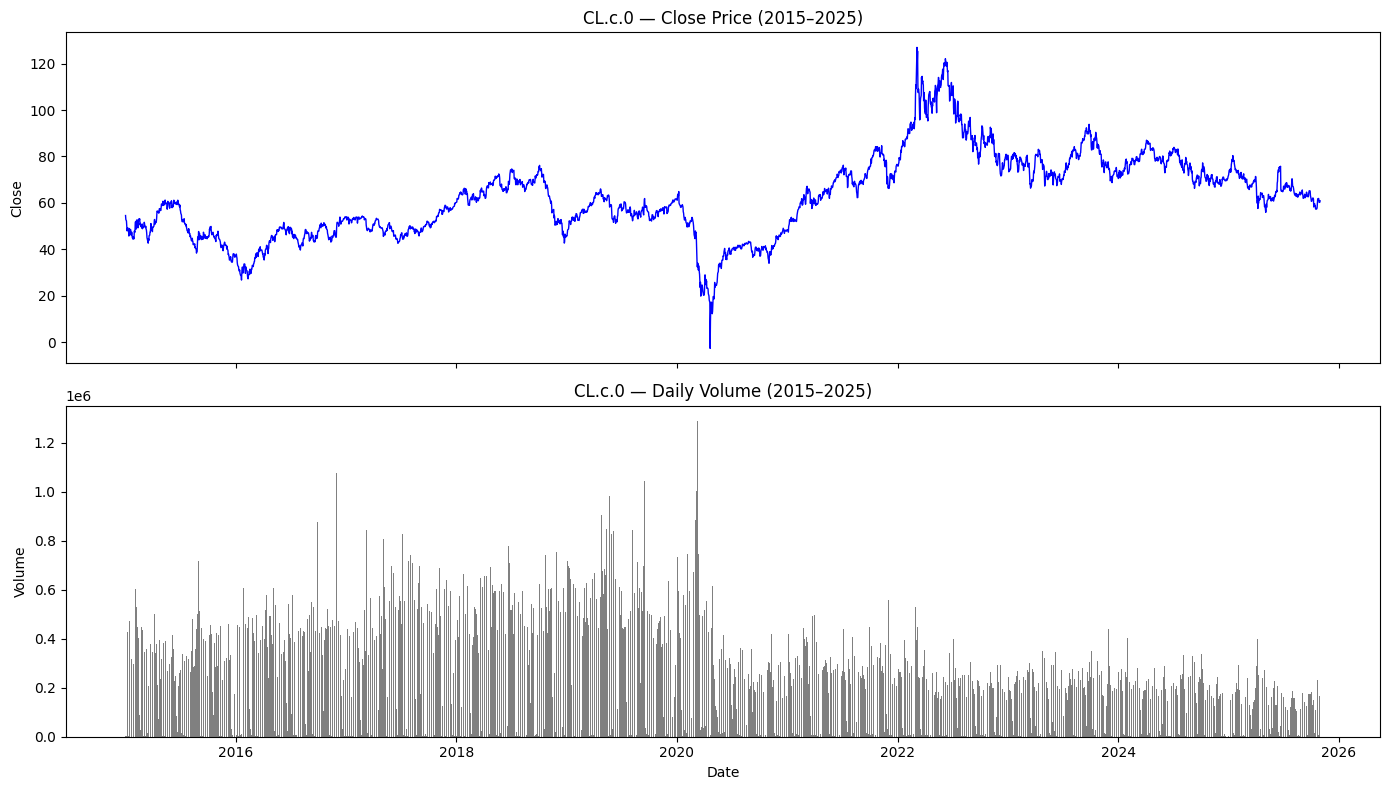

Plotting CL.c.1...


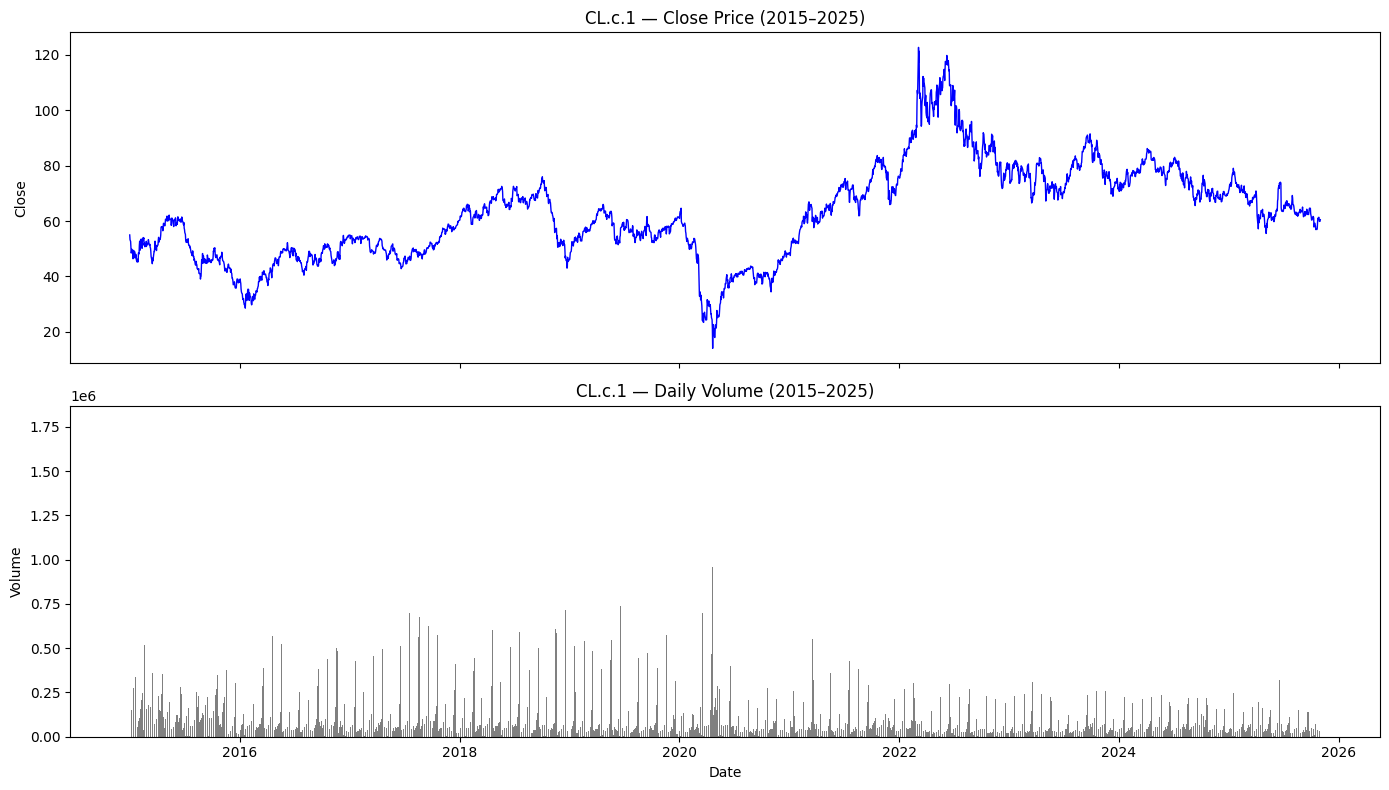

Plotting CL.c.2...


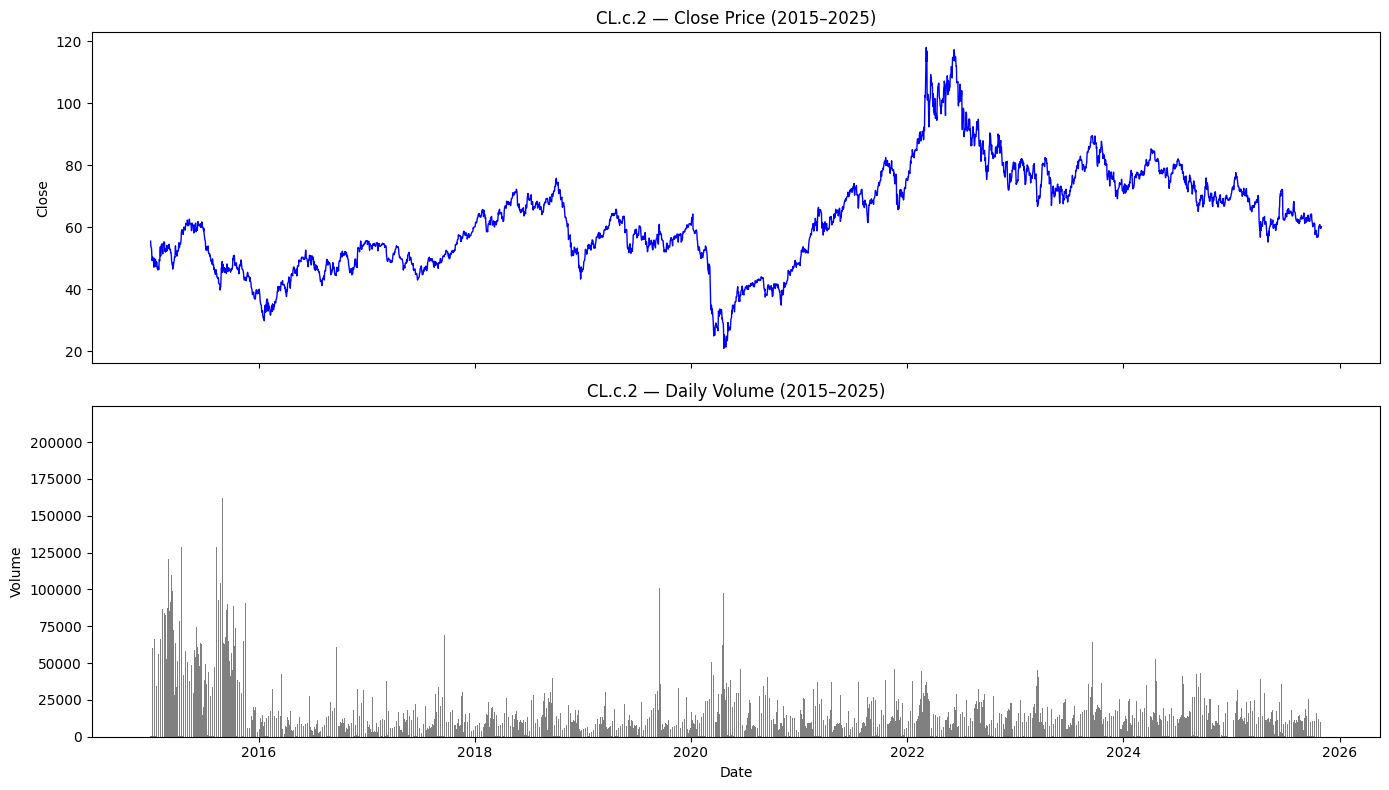

In [ ]:
symbols = ["CL.c.0", "CL.c.1", "CL.c.2"]

for sym in symbols:
    print(f"Plotting {sym}...")
    
    sub = full[full["symbol"] == sym].copy()
    sub = sub.sort_values("ts_event")

    if sub.empty:
        print(f"No data found for {sym}\n")
        continue

    # Plot
    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # close price
    ax[0].plot(sub["ts_event"], sub["close"], color="blue", linewidth=1)
    ax[0].set_title(f"{sym} — Close Price (2015–2025)")
    ax[0].set_ylabel("Close")

    # volume
    ax[1].bar(sub["ts_event"], sub["volume"], color="gray", width=1)
    ax[1].set_title(f"{sym} — Daily Volume (2015–2025)")
    ax[1].set_ylabel("Volume")
    ax[1].set_xlabel("Date")

    plt.tight_layout()
    plt.show()
